In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.shape

(5572, 5)

In [4]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [6]:
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [8]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [10]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4457, 5000)
Testing shape: (1115, 5000)


In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

nb_model = MultinomialNB()
lr_model = LogisticRegression(max_iter=1000)
svm_model = LinearSVC()

nb_model.fit(X_train_tfidf, y_train)
lr_model.fit(X_train_tfidf, y_train)
svm_model.fit(X_train_tfidf, y_train)

print("All models trained successfully!")

All models trained successfully!


In [13]:
nb_pred = nb_model.predict(X_test_tfidf)
lr_pred = lr_model.predict(X_test_tfidf)
svm_pred = svm_model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "SVM": svm_pred
}

results = []

for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.972197,0.991667,0.798658,0.884758
1,Logistic Regression,0.970404,1.000000,0.778523,0.875472
2,SVM,0.984753,0.992537,0.892617,0.939929


In [15]:
best_model_name = results_df.loc[
    results_df['F1 Score'].idxmax(), 'Model'
]

print("Best Model:", best_model_name)

Best Model: SVM


In [16]:
results_df.sort_values('F1 Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,SVM,0.984753,0.992537,0.892617,0.939929
0,Naive Bayes,0.972197,0.991667,0.798658,0.884758
1,Logistic Regression,0.970404,1.000000,0.778523,0.875472


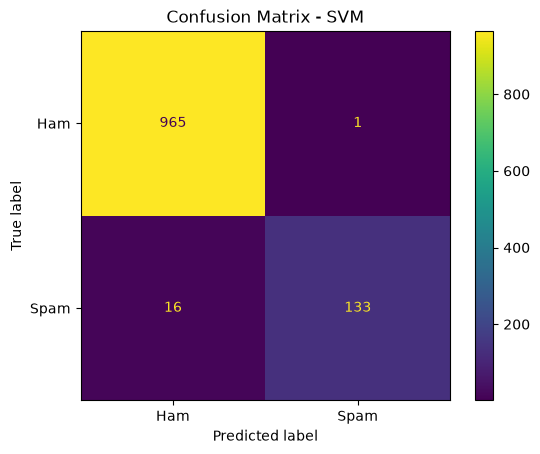

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_pred = models[best_model_name]

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=['Ham', 'Spam']
)

plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [18]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

best_model = {
    "Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "SVM": svm_model
}[best_model_name]

joblib.dump(best_model, "../models/spam_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Best model and TF-IDF vectorizer saved successfully!")

Best model and TF-IDF vectorizer saved successfully!


In [19]:
def predict_spam(message):
    message_tfidf = tfidf.transform([message])
    prediction = best_model.predict(message_tfidf)[0]

    if prediction == 1:
        return "Spam 🚨"
    else:
        return "Legitimate ✅"


test_message = "Congratulations! You have won a free prize. Call now!"
print(predict_spam(test_message))

Spam 🚨


In [20]:
print(predict_spam("Hey, are we meeting at 5 pm today?"))

Legitimate ✅
